In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

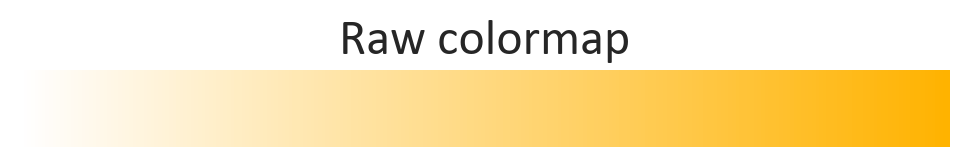

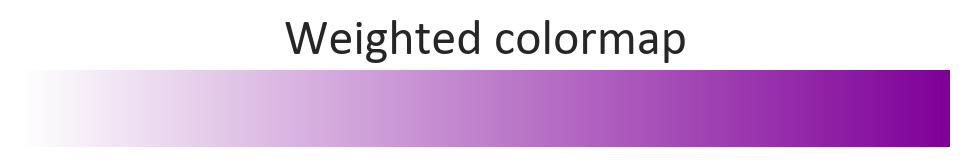

In [2]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

# Add font family to the rcParams (from tff file)
from matplotlib import font_manager

font_path = "/home/galkepler/.fonts/calibri-regular.ttf"
font_manager.fontManager.addfont(font_path)


mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "Calibri",
        # "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "font.sans-serif": ["Calibri", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, transparent=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=transparent, **savefig_kwargs)

mpl.rcParams["font.family"] = "Calibri"  # or any other font you want

# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [3]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
# DATA_DIR = Path("/media/groot/Minerva/phd/neuroaging/data")
DATA_DIR = Path("/media/storage/phd/neuroaging/data")

# Output directory for figures
# OUTPUT_DIR = Path("/media/groot/Minerva/phd/neuroaging/figures/revision/fig3")
OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/revision/fig3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [4]:
metrics = ["gm_vol", "adc"]
distribution_metric = "qfmean"

bad_subjects = ["IN120120"]

# Load the data
all_data = {}
for metric in metrics:
    all_data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
        drop=True
    )
    # drop problematic subjects
    all_data[metric] = all_data[metric][~all_data[metric]["subject_code"].isin(bad_subjects)]
    all_data[metric]["sex"] = all_data[metric]["sex"].map({"M": 0, "F": 1})


# data["age_squared"] = data["age_at_scan"] ** 2

/tmp/ipykernel_1613853/485535177.py:9: DtypeWarning: Columns (1,7,61,67,71,72,73,74,75,77,78,79,80,85,86,87,88,89,90,92,106,108,109,114,115,116,117,118,125,126,127) have mixed types. Specify dtype option on import or set low_memory=False.
  all_data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
/tmp/ipykernel_1613853/485535177.py:9: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  all_data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(


In [5]:
metric_cols = {metric: "volume" if "vol" in metric else distribution_metric for metric in metrics}

for m, df in all_data.items():
    df = df.rename(columns={metric_cols[m]: "value"})
    all_data[m] = df

In [6]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [7]:
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────────────────────
def compute_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    start_col: str = "range_start",
    end_col: str = "range_end",
    pop_total_col: str = "total",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Post-stratification weights so that the age distribution of *sample_df*
    matches an external population distribution supplied in *pop_df*.

    Parameters
    ----------
    sample_df : DataFrame with an ``age_col`` column (years; int or float).
    pop_df    : DataFrame with columns
                    [start_col, end_col, pop_total_col].
                * Values in ``pop_total_col`` can be counts **or** percentages
                  (they are internally re-scaled to proportions).
                * The row order doesn’t matter; they will be sorted.
    cap       : Optional float.  If provided, weights are truncated at
                ``cap × mean(weight)`` and then re-scaled so mean(weight)=1.
    return_bin_table : If True, also return a DataFrame summarising
                       n_sample, n_pop, and weight_factor for every bin.

    Returns
    -------
    weights   : 1-D numpy array aligned with ``sample_df.index``.
    bin_table : (optional) tidy per-bin summary (see above).
    """

    # 1 ── tidy & validate the population table --------------------------------
    pop = (
        pop_df[[start_col, end_col, pop_total_col]]
        .dropna()
        .astype({start_col: int, end_col: int, pop_total_col: float})
        .sort_values(start_col)  # your CSV is descending; fix that
        .reset_index(drop=True)
    )

    if (pop[end_col] <= pop[start_col]).any():
        raise ValueError("Each range_end must exceed range_start.")

    if (pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values).any():
        overlap = pop.iloc[
            np.where(pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values)[0] + 1
        ][[start_col, end_col]]
        raise ValueError(
            "Age bins overlap (rows shown below) — "
            "merge / correct them before weighting:\n"
            f"{overlap}"
        )

    # 2 ── build right-inclusive bin edges  (···| s_i  …  e_i | s_{i+1} …) ----
    edges = pop[start_col].tolist() + [pop[end_col].iloc[-1]]

    # 3 ── assign every participant to a bin -----------------------------------
    s_bins = pd.cut(
        sample_df[age_col],
        bins=edges,
        right=True,
        include_lowest=True,
        labels=pop.index,  # categorical labels 0,1,…
    )

    # 4 ── compute *sample* and *population* proportions per bin --------------
    n_sample = s_bins.value_counts(sort=False).sort_index()
    prop_sample = n_sample / n_sample.sum()

    prop_pop = pop[pop_total_col] / pop[pop_total_col].sum()

    # 5 ── weight factor = pop_prop / sample_prop ------------------------------
    weight_factor = prop_pop / prop_sample.replace(0, np.nan)  # avoid /0 → NaN

    # 6 ── map factor back to each row ----------------------------------------
    w = s_bins.map(weight_factor).astype(float).to_numpy()
    w = np.where(np.isnan(w), 0.0, w)  # rows that fell outside bins → 0

    # 7 ── optional weight truncation (winsorisation) --------------------------
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean()
        w = np.clip(w, 0, cap * mean_pos)

    # 8 ── re-scale so mean(weight > 0) == 1 -----------------------------------
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    # 9 ── return --------------------------------------------------------------
    if return_bin_table:
        bin_tbl = pd.DataFrame(
            {
                "n_sample": n_sample,
                "n_pop": prop_pop * n_sample.sum(),  # rescaled to sample size
                "prop_sample": prop_sample,
                "prop_pop": prop_pop,
                "weight_factor": weight_factor,
            }
        )
        return w, bin_tbl

    return w

In [8]:
import numpy as np
import pandas as pd

def compute_joint_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    sex_col: str = "sex",
    male_label = 0,
    female_label = 1,
    start_col: str = "range_start",
    end_col: str = "range_end",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Computes joint post-stratification weights for Age and Sex so the sample
    matches an external census distribution.
    
    Parameters
    ----------
    sample_df : DataFrame with age and sex columns.
    pop_df    : DataFrame with [range_start, range_end, male, female].
    male_label/female_label : The values used in sample_df['sex'] (e.g., 0 and 1).
    cap       : Optional multiplier to truncate extreme weights.
    """
    # 1. Validation: Ensure all columns exist
    required_sample = [age_col, sex_col]
    required_pop = [start_col, end_col, "male", "female"]
    
    for col in required_sample:
        if col not in sample_df.columns:
            raise KeyError(f"Column '{col}' not found in sample_df. Available: {list(sample_df.columns)}")
    for col in required_pop:
        if col not in pop_df.columns:
            raise KeyError(f"Column '{col}' not found in pop_df. Available: {list(pop_df.columns)}")

    # 2. Tidy population table and convert to Long Format
    pop = pop_df.sort_values(start_col).copy()
    pop_long = pop.melt(
        id_vars=[start_col, end_col],
        value_vars=['male', 'female'],
        var_name='sex_str',
        value_name='pop_val'
    )
    
    # Map 'male'/'female' strings to the labels in your sample (0 and 1)
    pop_long[sex_col] = pop_long['sex_str'].map({'male': male_label, 'female': female_label})
    pop_long['prop_pop'] = pop_long['pop_val'] / pop_long['pop_val'].sum()
    
    # 3. Create Age Bins
    # edges define brackets: [0, 5, 10, ..., 90, 1000001]
    edges = sorted(list(pop[start_col].unique()) + [int(pop[end_col].max()) + 1])
    bin_labels = sorted(list(pop[start_col].unique()))
    
    sample = sample_df.copy()
    sample['age_bin_start'] = pd.cut(
        sample[age_col], 
        bins=edges, 
        labels=bin_labels, 
        right=False # standard for age: [start, end)
    )
    
    if sample['age_bin_start'].isna().any():
        print("Warning: Some participants fall outside the census age ranges.")

    # 4. Calculate Sample Proportions per (Age, Sex) cell
    sample_counts = sample.groupby(['age_bin_start', sex_col], observed=False).size().reset_index(name='n_sample')
    sample_counts['prop_sample'] = sample_counts['n_sample'] / sample_counts['n_sample'].sum()
    
    # Ensure types match for merging
    sample_counts['age_bin_start'] = sample_counts['age_bin_start'].astype(pop_long[start_col].dtype)
    
    # 5. Calculate Weight Factors (Population Proportion / Sample Proportion)
    weights_lookup = pd.merge(
        pop_long[[start_col, sex_col, 'prop_pop']],
        sample_counts,
        left_on=[start_col, sex_col],
        right_on=['age_bin_start', sex_col],
        how='left'
    )
    weights_lookup['weight_factor'] = weights_lookup['prop_pop'] / weights_lookup['prop_sample'].replace(0, np.nan)
    
    # 6. Map Weights back to individual sample rows
    sample['age_bin_start'] = sample['age_bin_start'].astype(pop_long[start_col].dtype)
    sample_with_weights = pd.merge(
        sample,
        weights_lookup[[start_col, sex_col, 'weight_factor']],
        left_on=['age_bin_start', sex_col],
        right_on=[start_col, sex_col],
        how='left'
    )
    
    w = sample_with_weights['weight_factor'].fillna(0).to_numpy()
    
    # 7. Apply optional cap and Rescale so mean weight = 1
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean() if any(w > 0) else 1.0
        w = np.clip(w, 0, cap * mean_pos)
        
    if any(w > 0):
        w = w / w.mean()
    else:
        print("Error: No matches found between sample and census. Weights are all zero.")

    if return_bin_table:
        return w, weights_lookup

    

    return w

In [9]:
# assign weights
for metric in metrics:
    all_data[metric]["weight"], _ = compute_joint_poststrat_weights(
    all_data[metric],
    israel_population,
    age_col="age_at_scan",
    sex_col="sex",
    return_bin_table=True,
    cap=10  # Optional: prevents any single female/male from having too much influence
)
    all_data[metric]["subject_code"] = all_data[metric]["subject_code"].astype(str).str.zfill(4)

In [10]:
# from tqdm import tqdm

# # Set up dataframes to store results

# models = {}

# for metric in metrics:
#     models[metric] = {}
#     # for save_name in ["lin_unw", "lin_w", "quad_unw", "quad_w", "unw_compare", "w_compare"]:
#     for save_name in ["lin_w", "quad_w", "w_compare"]:
#         models[metric][save_name] = pd.read_pickle(
#             OUTPUT_DIR.with_name("fig2") / f"{save_name}_{metric}_centered.pkl"
#         )

In [11]:
# Tell the pipeline which side of the parabola is "structural stabilisation"
orientation = {  # feel free to expand
    "gm_vol": "max",  # concave-down expected
    "adc": "min",  # concave-up expected
    # "fa"   : "min",
    # "rd"   : "min",
}


def vertex_age(beta1, beta2):
    # Age at vertex of a quadratic beta0 + beta1*x + beta2*x^2.
    return -beta1 / (2 * beta2)


def stabilization_age(metric, betas, mean_age, *, age_min=18, age_max=75):
    b1, b2 = betas["age"], betas["age_sq"]
    
    # 1. Determine if the shape is 'biologically expected'
    is_u_shaped = b2 > 0
    if "vol" in metric:
        valid_shape = not is_u_shaped  # Expect Inverted-U (beta2 < 0)
    else:
        valid_shape = is_u_shaped      # Expect U-shape (beta2 > 0)

    if not valid_shape:
        # Return age_min as a default 'clipped' value instead of NaN 
        # to prevent downstream plotting/analysis errors
        return age_min, True, is_u_shaped

    # 2. Compute vertex (Corrected: add the mean_age shift)
    v_centered = -b1 / (2 * b2)
    age_star = mean_age + v_centered
    
    # 3. Clip and flag
    clipped = False
    if age_star < age_min:
        age_star, clipped = age_min, True
    elif age_star > age_max:
        age_star, clipped = age_max, True
        
    return age_star, clipped, is_u_shaped


In [13]:
from tqdm import tqdm
from statsmodels.formula.api import ols, wls
import statsmodels.formula.api as smf

regional_results = {}
mean_age_by_metric = {metric: data["age_at_scan"].mean() for metric, data in all_data.items()}

for metric, data in all_data.items():
    metric_col = "volume" if metric == "gm_vol" else distribution_metric
    # Set up dataframes to store results
    quad_w, lin_w = parcels.copy(), parcels.copy()

    mean_age = mean_age_by_metric[metric]

    covariates = ["age_c", "C(sex)"]
    if metric == "gm_vol":
        covariates += ["tiv"]

    for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
        region_data = data[data[region_col] == row[region_col]].copy()
        region_data.rename(columns={metric_col: "value"}, inplace=True)
        region_data["age_c"] = region_data["age_at_scan"] - mean_age
        # region_data["age_c"] = region_data["age_at_scan"]
        region_data["age_c2"] = region_data["age_c"] ** 2

        lin_model = smf.wls(
            "value ~ " + " + ".join(covariates),
            data=region_data,
            weights=region_data["weight"],
        ).fit()
        quad_model = smf.wls(
            "value ~ " + " + ".join(covariates) + " + I(age_c ** 2)",
            data=region_data,
            weights=region_data["weight"],
        ).fit()

        f, p, _ = quad_model.compare_f_test(lin_model)
        delta_aic = quad_model.aic - lin_model.aic
        for results_df, model, is_quadratic in zip(
            [lin_w, quad_w],
            [lin_model, quad_model],
            [False, True],
        ):
            # Store the results
            results_df.loc[i, "model"] = model
            results_df.loc[i, "aic"] = model.aic
            results_df.loc[i, "pvalue"] = model.f_pvalue
            results_df.loc[i, "r2"] = model.rsquared
            results_df.loc[i, "r2_adj"] = model.rsquared_adj
            results_df.loc[i, "n"] = len(region_data)
            results_df.loc[i, "intercept"] = model.params["Intercept"]
            results_df.loc[i, "t_intercept"] = model.tvalues["Intercept"]
            results_df.loc[i, "pvalue_intercept"] = model.pvalues["Intercept"]
            results_df.loc[i, "beta1"] = model.params["age_c"]
            results_df.loc[i, "se_beta1"] = model.bse["age_c"]
            results_df.loc[i, "t_beta1"] = model.tvalues["age_c"]
            results_df.loc[i, "pvalue_beta1"] = model.pvalues["age_c"]

            if is_quadratic:
                results_df.loc[i, "beta2"] = model.params["I(age_c ** 2)"]
                results_df.loc[i, "se_beta2"] = model.bse["I(age_c ** 2)"]
                results_df.loc[i, "t_beta2"] = model.tvalues["I(age_c ** 2)"]
                results_df.loc[i, "pvalue_beta2"] = model.pvalues["I(age_c ** 2)"]
                beta1, beta2 = (
                    model.params["age_c"],
                    model.params["I(age_c ** 2)"],
                )
                if delta_aic < -15:
                    # We only attempt to find a vertex if the quadratic is significantly better
                    age_star, clipped, u = stabilization_age(
                        metric,
                        {"age": quad_model.params["age_c"], "age_sq": quad_model.params["I(age_c ** 2)"]},
                        mean_age
                    )
                else:
                    # For linear or non-sig models, we default to the start of the lifespan
                    age_star, clipped, u = 18, True, (quad_model.params["I(age_c ** 2)"] > 0)
                results_df.loc[i, "age_star"] = age_star
                results_df.loc[i, "clipped"] = clipped
            else:
                results_df.loc[i, "beta2"] = 0
                results_df.loc[i, "se_beta2"] = 0
                results_df.loc[i, "t_beta2"] = 0
                results_df.loc[i, "pvalue_beta2"] = 1
                results_df.loc[i, "age_star"] = 18
                results_df.loc[i, "clipped"] = True

    regional_results[metric] = {
        "lin_w": lin_w,
        "quad_w": quad_w,
    }


Fitting models: 100%|██████████| 454/454 [00:13<00:00, 33.29it/s]


In [14]:
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

for metric, results in regional_results.items():
    w_compare = parcels.copy()

    # do f test to compare between quadratic and linear models
    for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
        # collect models
        model1 = results["lin_w"].loc[i, "model"]
        model2 = results["quad_w"].loc[i, "model"]
        f, p, _ = model2.compare_f_test(model1)
        w_compare.loc[i, "f"] = f
        w_compare.loc[i, "pvalue"] = p
        w_compare.loc[i, "n"] = model1.nobs
        w_compare.loc[i, "AIC(lin)"] = model1.aic
        w_compare.loc[i, "AIC(quad)"] = model2.aic
        w_compare.loc[i, "delta_AIC"] = model2.aic - model1.aic
        w_compare["log(f)"] = np.log(w_compare["f"])
    # Save the comparison results
    w_compare["p_corrected"] = multipletests(w_compare["pvalue"], method="fdr_bh")[
        1
    ]  # Benjamini-Hochberg correction
    regional_results[metric]["w_compare"] = w_compare
    # do f test to compare between quadratic and linear models
    # model1 = lin_unw.loc[i, "model"]
    # model2 = quad_unw.loc[i, "model"]
    # f, p, _ = model2.compare_f_test(model1)
    # unw_compare.loc[i, "f"] = f
    # unw_compare.loc[i, "pvalue"] = p
    # unw_compare.loc[i, "n"] = model1.nobs
    # weighted

Fitting models: 100%|██████████| 454/454 [00:00<00:00, 860.21it/s] 


In [60]:
# alpha = 0.05
# aic_threshold = -5

# mean_age_by_metric = {metric: data["age_at_scan"].mean() for metric, data in all_data.items()}


# for metric in metrics:
#     stab_df = parcels.copy()

#     age_min = np.nan
#     mean_age = mean_age_by_metric[metric]

#     for i, row in parcels.iterrows():
#         lm = models[metric]["lin_w"].loc[i, "model"]
#         qm = models[metric]["quad_w"].loc[i, "model"]
#         p = models[metric]["w_compare"].loc[i, "p_corrected"]
#         delta_aic = models[metric]["w_compare"].loc[i, "delta_AIC"]
#         if delta_aic < aic_threshold:
#             age_star, clipped, u = stabilization_age(
#                         metric,
#                         {"age": qm.params["age_c"], "age_sq": qm.params["age_c2"]},
#                         mean_age
#                     )
#             chosen = "quadratic"
#         else:
#             age_star = age_min  # or age_max / np.nan
#             clipped = True
#             chosen = "linear"

#         # Save the results
#         stab_df.loc[i, "age_star"] = age_star
#         stab_df.loc[i, "clipped"] = clipped
#         stab_df.loc[i, "chosen"] = chosen
#         stab_df.loc[i, "p"] = p
#         stab_df.loc[i, "β1"] = β1 if chosen == "quadratic" else lm.params["age_at_scan"]
#         stab_df.loc[i, "β2"] = β2 if chosen == "quadratic" else 0.0
#         stab_df.loc[i, "r2_lin"] = lm.rsquared_adj
#         stab_df.loc[i, "r2_quad"] = qm.rsquared_adj
#         stab_df.loc[i, "delta_aic"] = delta_aic
#         stab_df.loc[i, "u"] = u

#     if "vol" in metric:  # expect inverted U
#         stab_df.loc[stab_df["u"], "clipped"] = True
#         stab_df.loc[stab_df["u"], "age_star"] = np.nan
#     else:
#         stab_df.loc[~stab_df["u"], "clipped"] = True
#         stab_df.loc[~stab_df["u"], "age_star"] = np.nan
#     models[metric]["stab_df"] = stab_df

In [61]:
# alpha = 0.05
# aic_threshold = -5
# age_min_obs = 18
# age_max_obs = 75

# age_col = "age_c"

# for metric in metrics:
#         # 1. Configuration
#     mean_age = data[metric]["age_at_scan"].mean()
#     data[metric][age_col] = data[metric]["age_at_scan"] - mean_age
#     stab_df = parcels.copy()

#     for i, row in parcels.iterrows():
#         lm = models[metric]["lin_w"].loc[i, "model"]
#         qm = models[metric]["quad_w"].loc[i, "model"]
#         p_comp = models[metric]["w_compare"].loc[i, "p_corrected"]
#         delta_aic = models[metric]["w_compare"].loc[i, "delta_AIC"]
        
#         # 2. Decision Logic: Is it robustly quadratic?
#         is_quad = (p_comp < alpha) and (delta_aic < aic_threshold)
        
#         if is_quad:
#             b1 = qm.params["age_c"]
#             b2 = qm.params["I(age_c ** 2)"]
            
#             # Calculate vertex in centered space
#             v_centered = -b1 / (2 * b2)
#             v_years = v_centered + mean_age
            
#             # Determine shape
#             is_u_shape = b2 > 0  # True = U, False = Inverted U
            
#             # 3. Biological Validity Check
#             # For Volume: We only want Inverted U (b2 < 0)
#             # For MD/ADC: We only want U-shape (b2 > 0)
#             valid_shape = (is_u_shape if "vol" not in metric else not is_u_shape)
            
#             if valid_shape:
#                 # Clip to observed range
#                 if v_years < age_min_obs:
#                     age_star, clipped = age_min_obs, True
#                 elif v_years > age_max_obs:
#                     age_star, clipped = age_max_obs, True
#                 else:
#                     age_star, clipped = v_years, False
#                 chosen = "quadratic"
#             else:
#                 # Right math, wrong biology (e.g., volume increasing then decreasing)``
#                 clipped, chosen = True, "invalid_shape"
#         else:
#             # Model is linear or non-significant
#             clipped, chosen = True, "linear"

#         # Save
#         stab_df.loc[i, ["age_star", "clipped", "chosen", "u", "r2_lin", "r2_quad", "delta_aic"]] = [age_star, clipped, chosen, (b2 > 0 if is_quad else None), lm.rsquared_adj, qm.rsquared_adj, delta_aic]
#     models[metric]["stab_df"] = stab_df

In [62]:
# find the most quadratic, unclipped, and significant
most_significant = {}
for metric in metrics:
    indices = regional_results[metric]["w_compare"].sort_values("delta_AIC").head(20).index
    most_significant[metric] = {
        "indices": indices,
        "stab_df": regional_results[metric]["w_compare"].loc[indices],
        "stab_df_unclipped": regional_results[metric]["w_compare"]
        .loc[regional_results[metric]["quad_w"]["clipped"] == False]
        .sort_values("delta_AIC")
        .head(10),
    }

In [63]:
# find shared ROIs
shared_rois = set(most_significant[metrics[0]]["indices"])
for metric in metrics[1:]:
    shared_rois.intersection_update(most_significant[metric]["indices"])
shared_rois

{405}

In [77]:
md_rois = {
    413: {"name": "R. Putamen", "component": "Basal Ganglia"},
    447: {"name": "L. Amygdala", "component": "Limbic System"},
    168: {"name": "L. PFC", "component": "Prefrontal Cortex"},
    179: {"name": "L. PFC", "component": "Prefrontal Cortex"},
    50: {"name": "L. Postcentral", "component": "Somatomotor"},
    258: {"name": "R. Precentral", "component": "Somatomotor"},
}

gm_rois = {
    426: {"name": "R. Pallidum", "component": "Basal Ganglia"},
}

# example_rois = [405,435, 421, 42] if "vol" in metric else [447, 179, 50]
# example_rois = [405, 432, 438, 421, 42, 447, 179, 50]
example_rois = [405, 179, 50, 214]

In [78]:
parcels.loc[example_rois]

# find regions where gm vol age_star > md age_star
# gm_stab = regional_results["gm_vol"]["quad_w"].copy()
# md_stab = regional_results["adc"]["quad_w"].copy()
# merged_stab = pd.merge(
#     gm_stab[["index", "age_star"]],
#     md_stab[["index", "age_star"]],
#     on="index",
#     suffixes=("_gm", "_md"),
# )
# regions_gm_later_than_md = merged_stab[merged_stab["age_star_gm"] > merged_stab["age_star_md"]]
# regions_gm_later_than_md

,index,name,base_name,Label Name,network,component,hemisphere
405,406,HIP-body-rh,HIP-body,Hippocampus body,subcortex,Hippocampus body,R
179,180,7Networks_LH_Default_PFC_15,7networks_lh_default_pfc,7Networks_LH_Default_PFC,default,prefrontal cortex,L
50,51,7Networks_LH_SomMot_20,7networks_lh_sommot,7Networks_LH_SomMot,somatomotor,somatomotor,L
214,215,7Networks_RH_Vis_15,7networks_rh_vis,7Networks_RH_Vis,visual,visual,R


In [66]:
metrics_vis = {"gm_vol": "GM Vol.", "adc": "MD"}

gm_vol --- Linear --- 0.4029250748401595
gm_vol --- Quadratic --- 0.44464180008350385
adc --- Linear --- 0.17739396525618223
adc --- Quadratic --- 0.3478572036909443


/tmp/ipykernel_3007055/3912973872.py:157: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(lines, labels, frameon=False, fontsize=35, loc="upper right")


gm_vol --- Linear --- 0.5169415437344163
gm_vol --- Quadratic --- 0.5228057298432045
adc --- Linear --- 0.2090110339429584
adc --- Quadratic --- 0.27854703223299426


/tmp/ipykernel_3007055/3912973872.py:157: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(lines, labels, frameon=False, fontsize=35, loc="upper right")


gm_vol --- Linear --- 0.27892328651008447
gm_vol --- Quadratic --- 0.27944292256265224
adc --- Linear --- 0.2724377110794699
adc --- Quadratic --- 0.2732955204201645


/tmp/ipykernel_3007055/3912973872.py:157: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(lines, labels, frameon=False, fontsize=35, loc="upper right")


gm_vol --- Linear --- 0.4084572587412797
gm_vol --- Quadratic --- 0.4234284979287787
adc --- Linear --- 0.25207929693189934
adc --- Quadratic --- 0.2753945262029116


/tmp/ipykernel_3007055/3912973872.py:157: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(lines, labels, frameon=False, fontsize=35, loc="upper right")


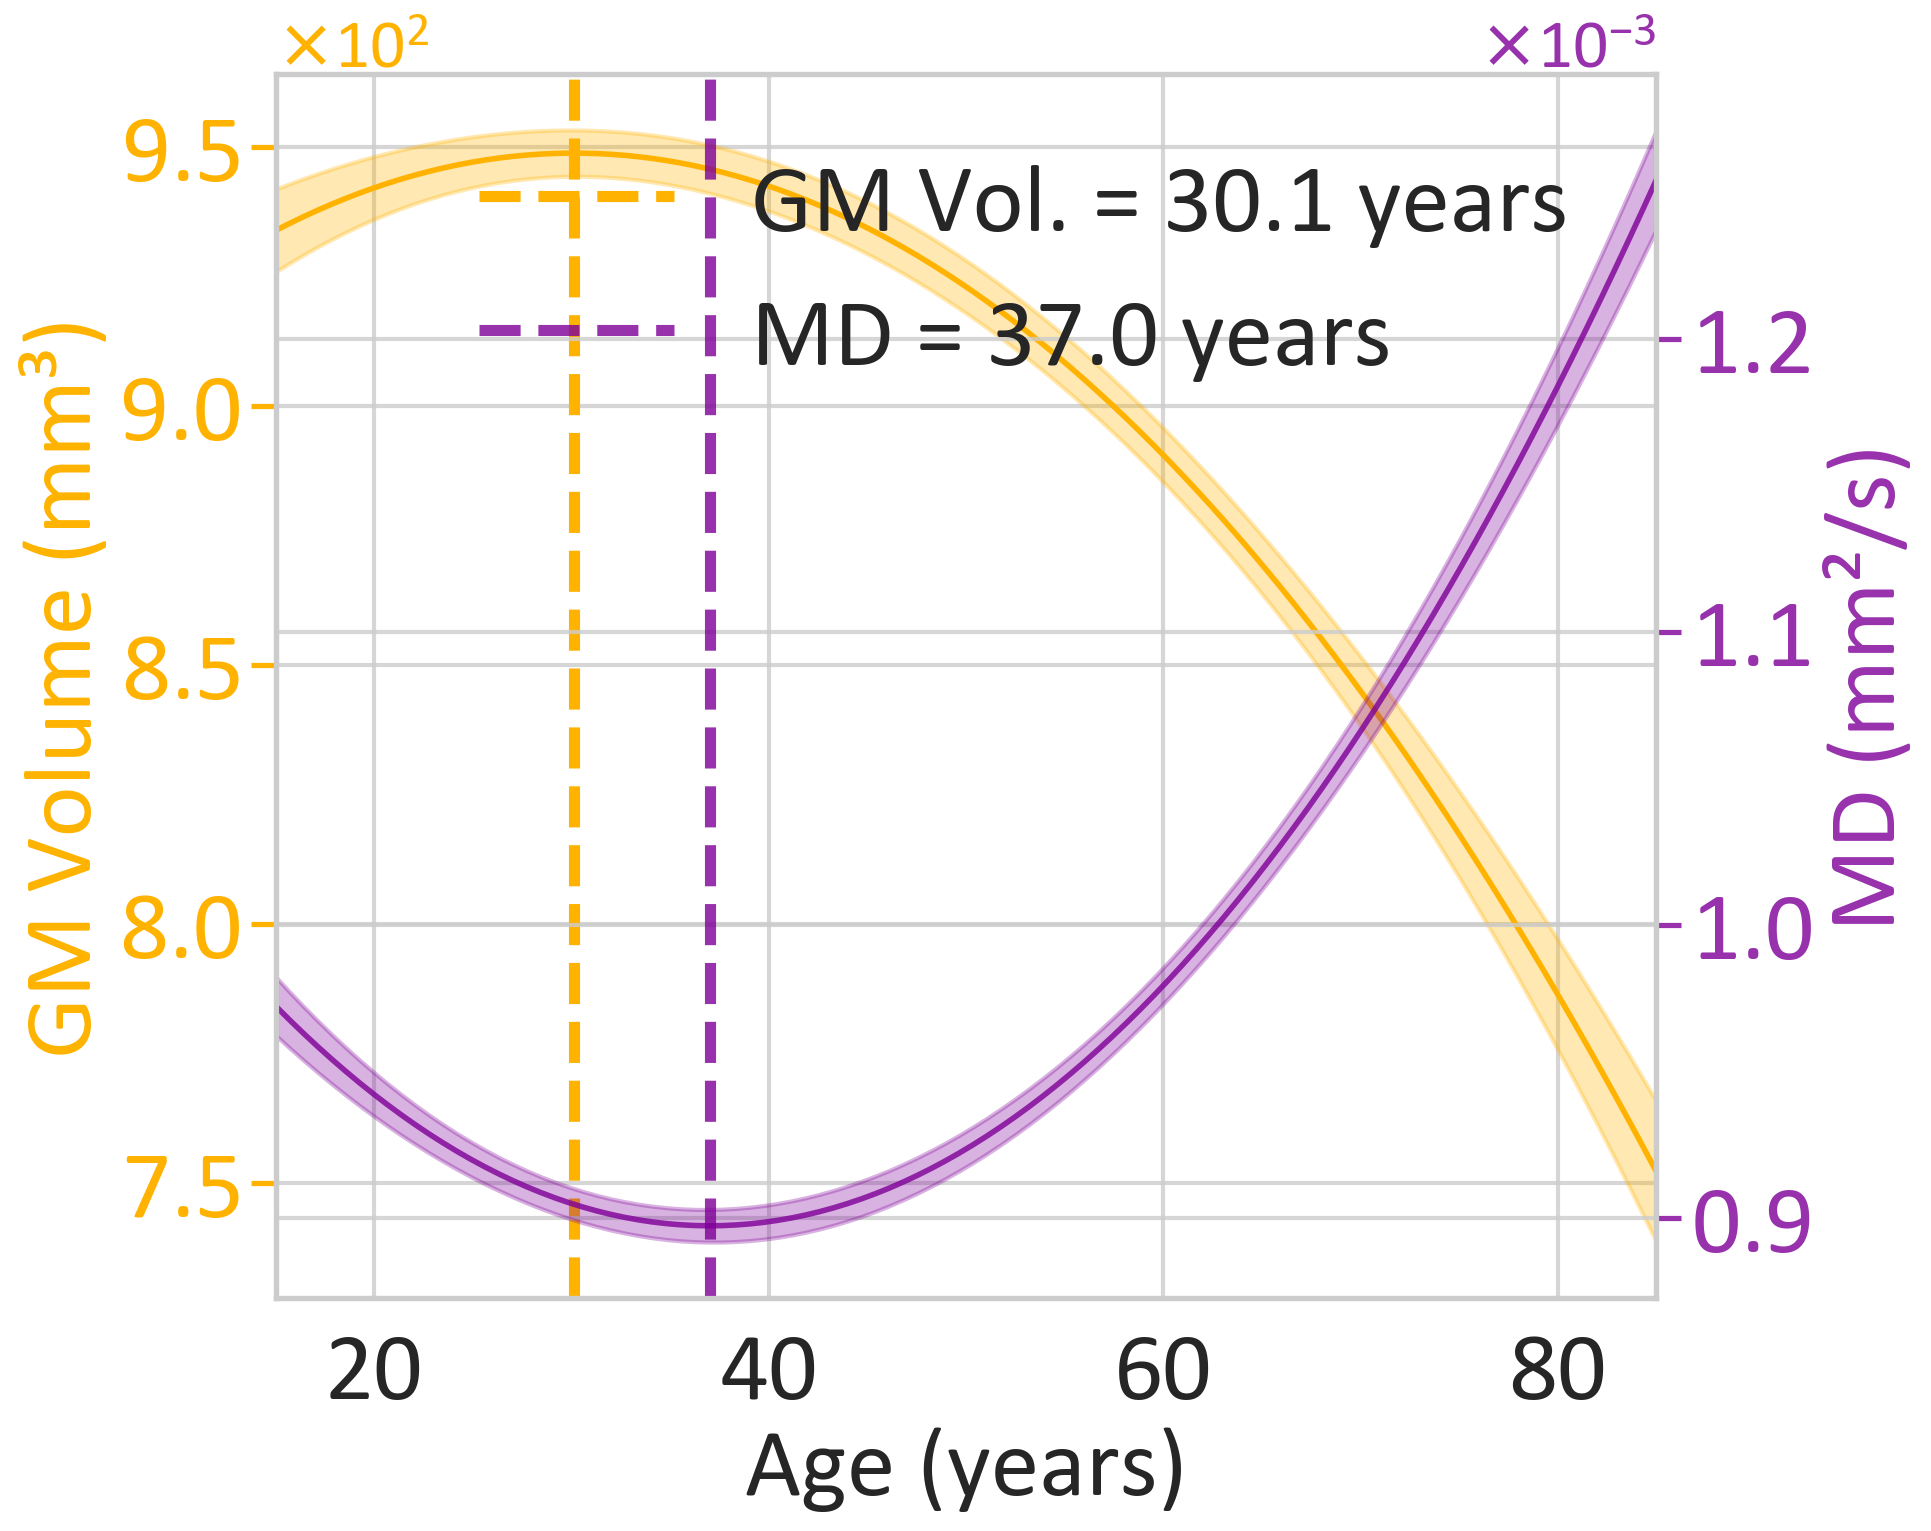

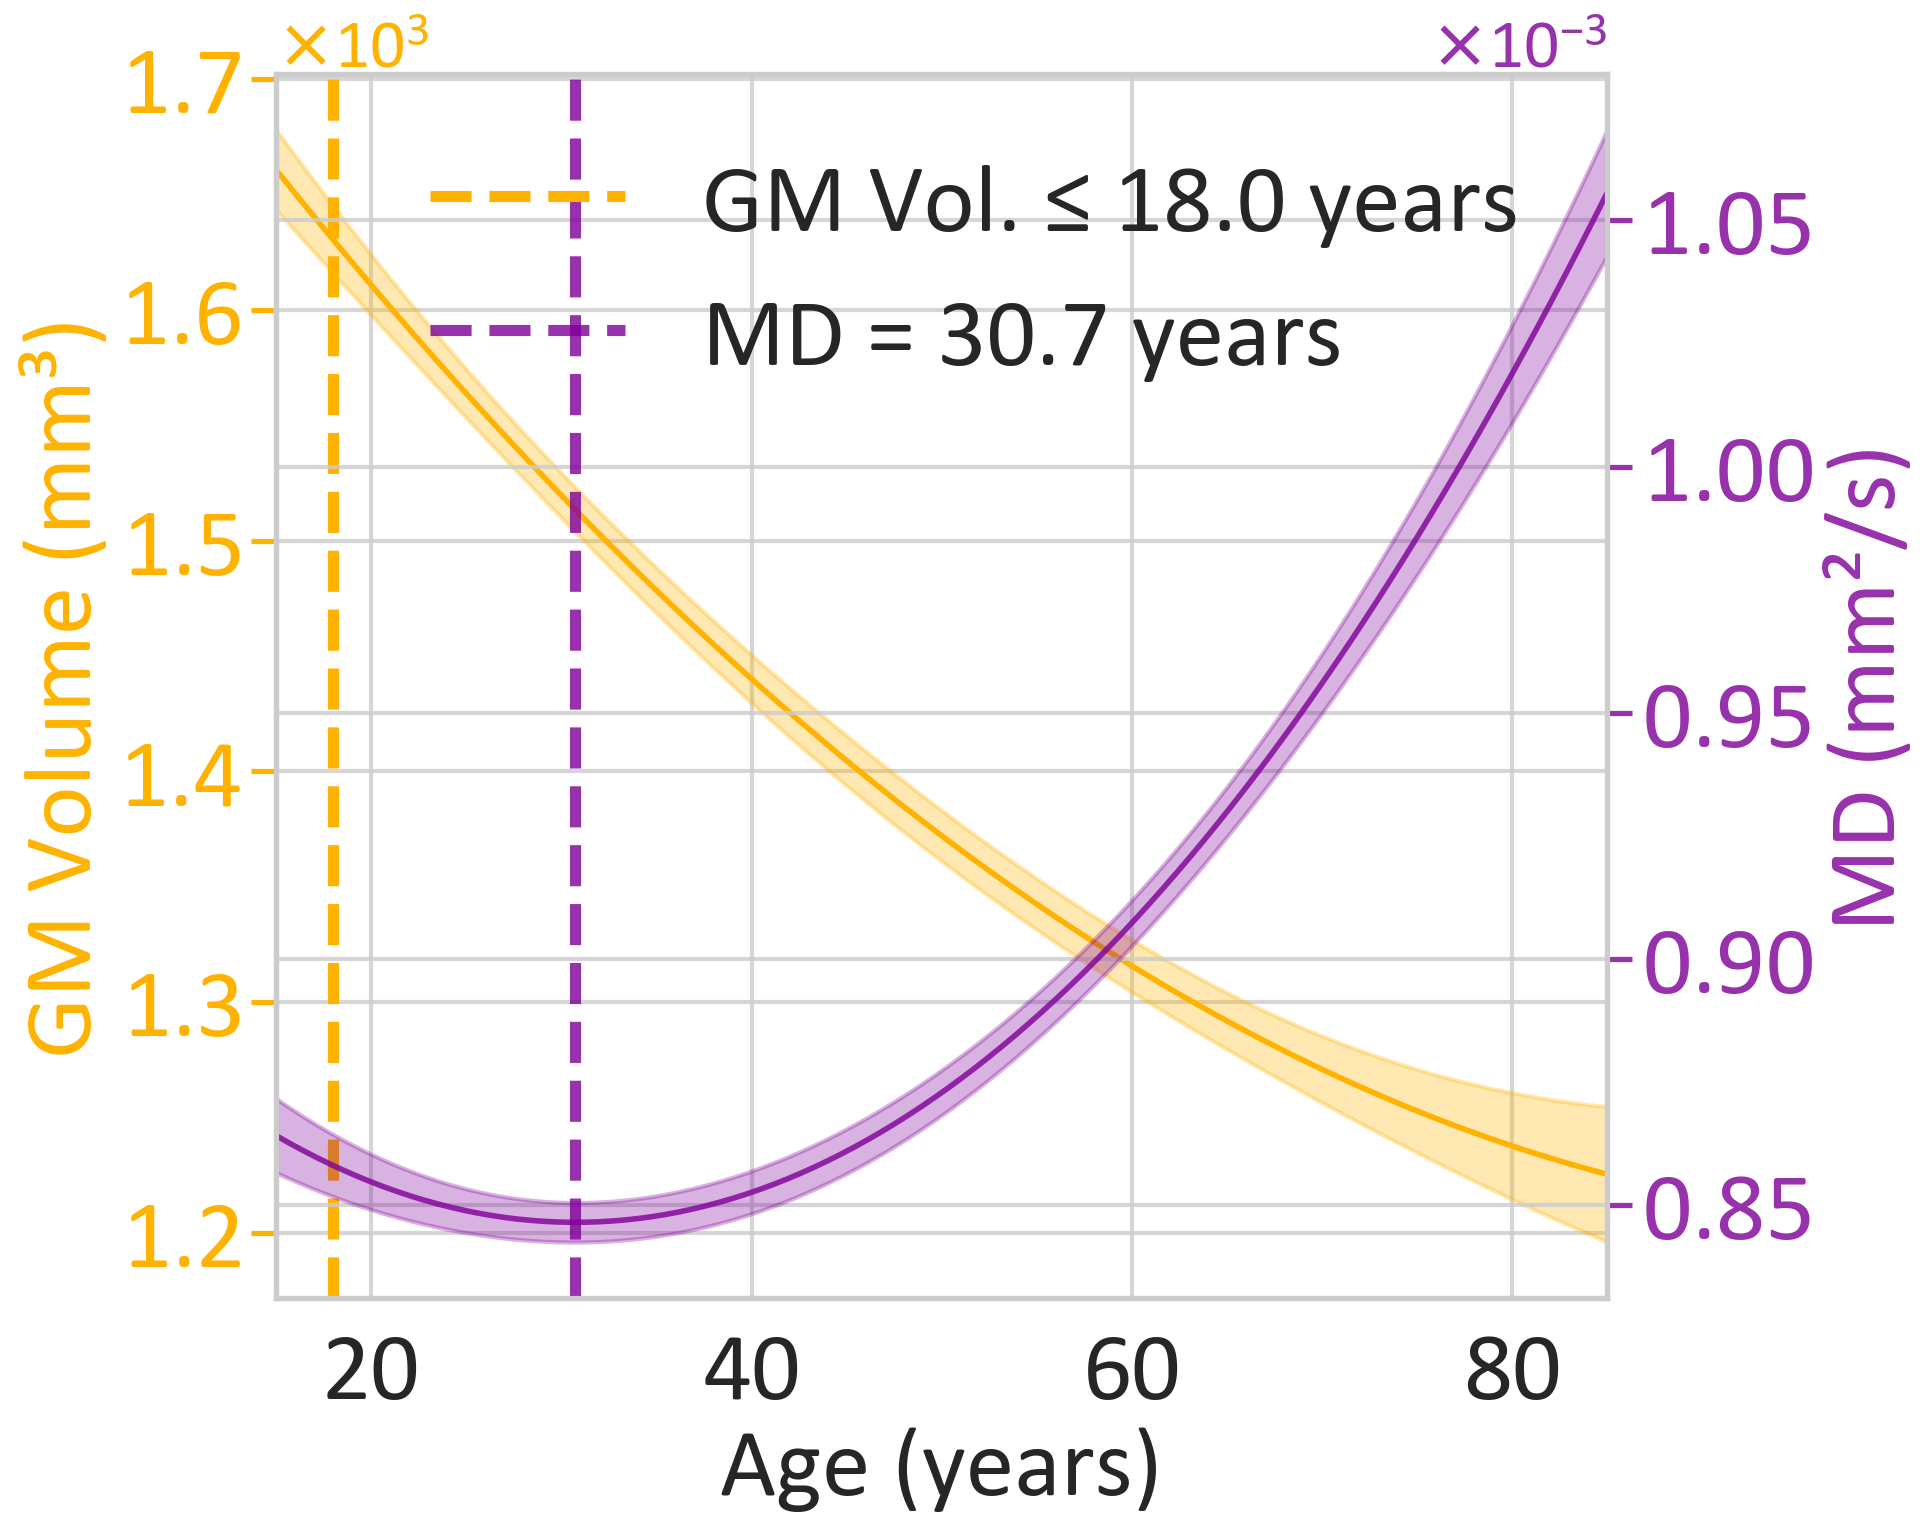

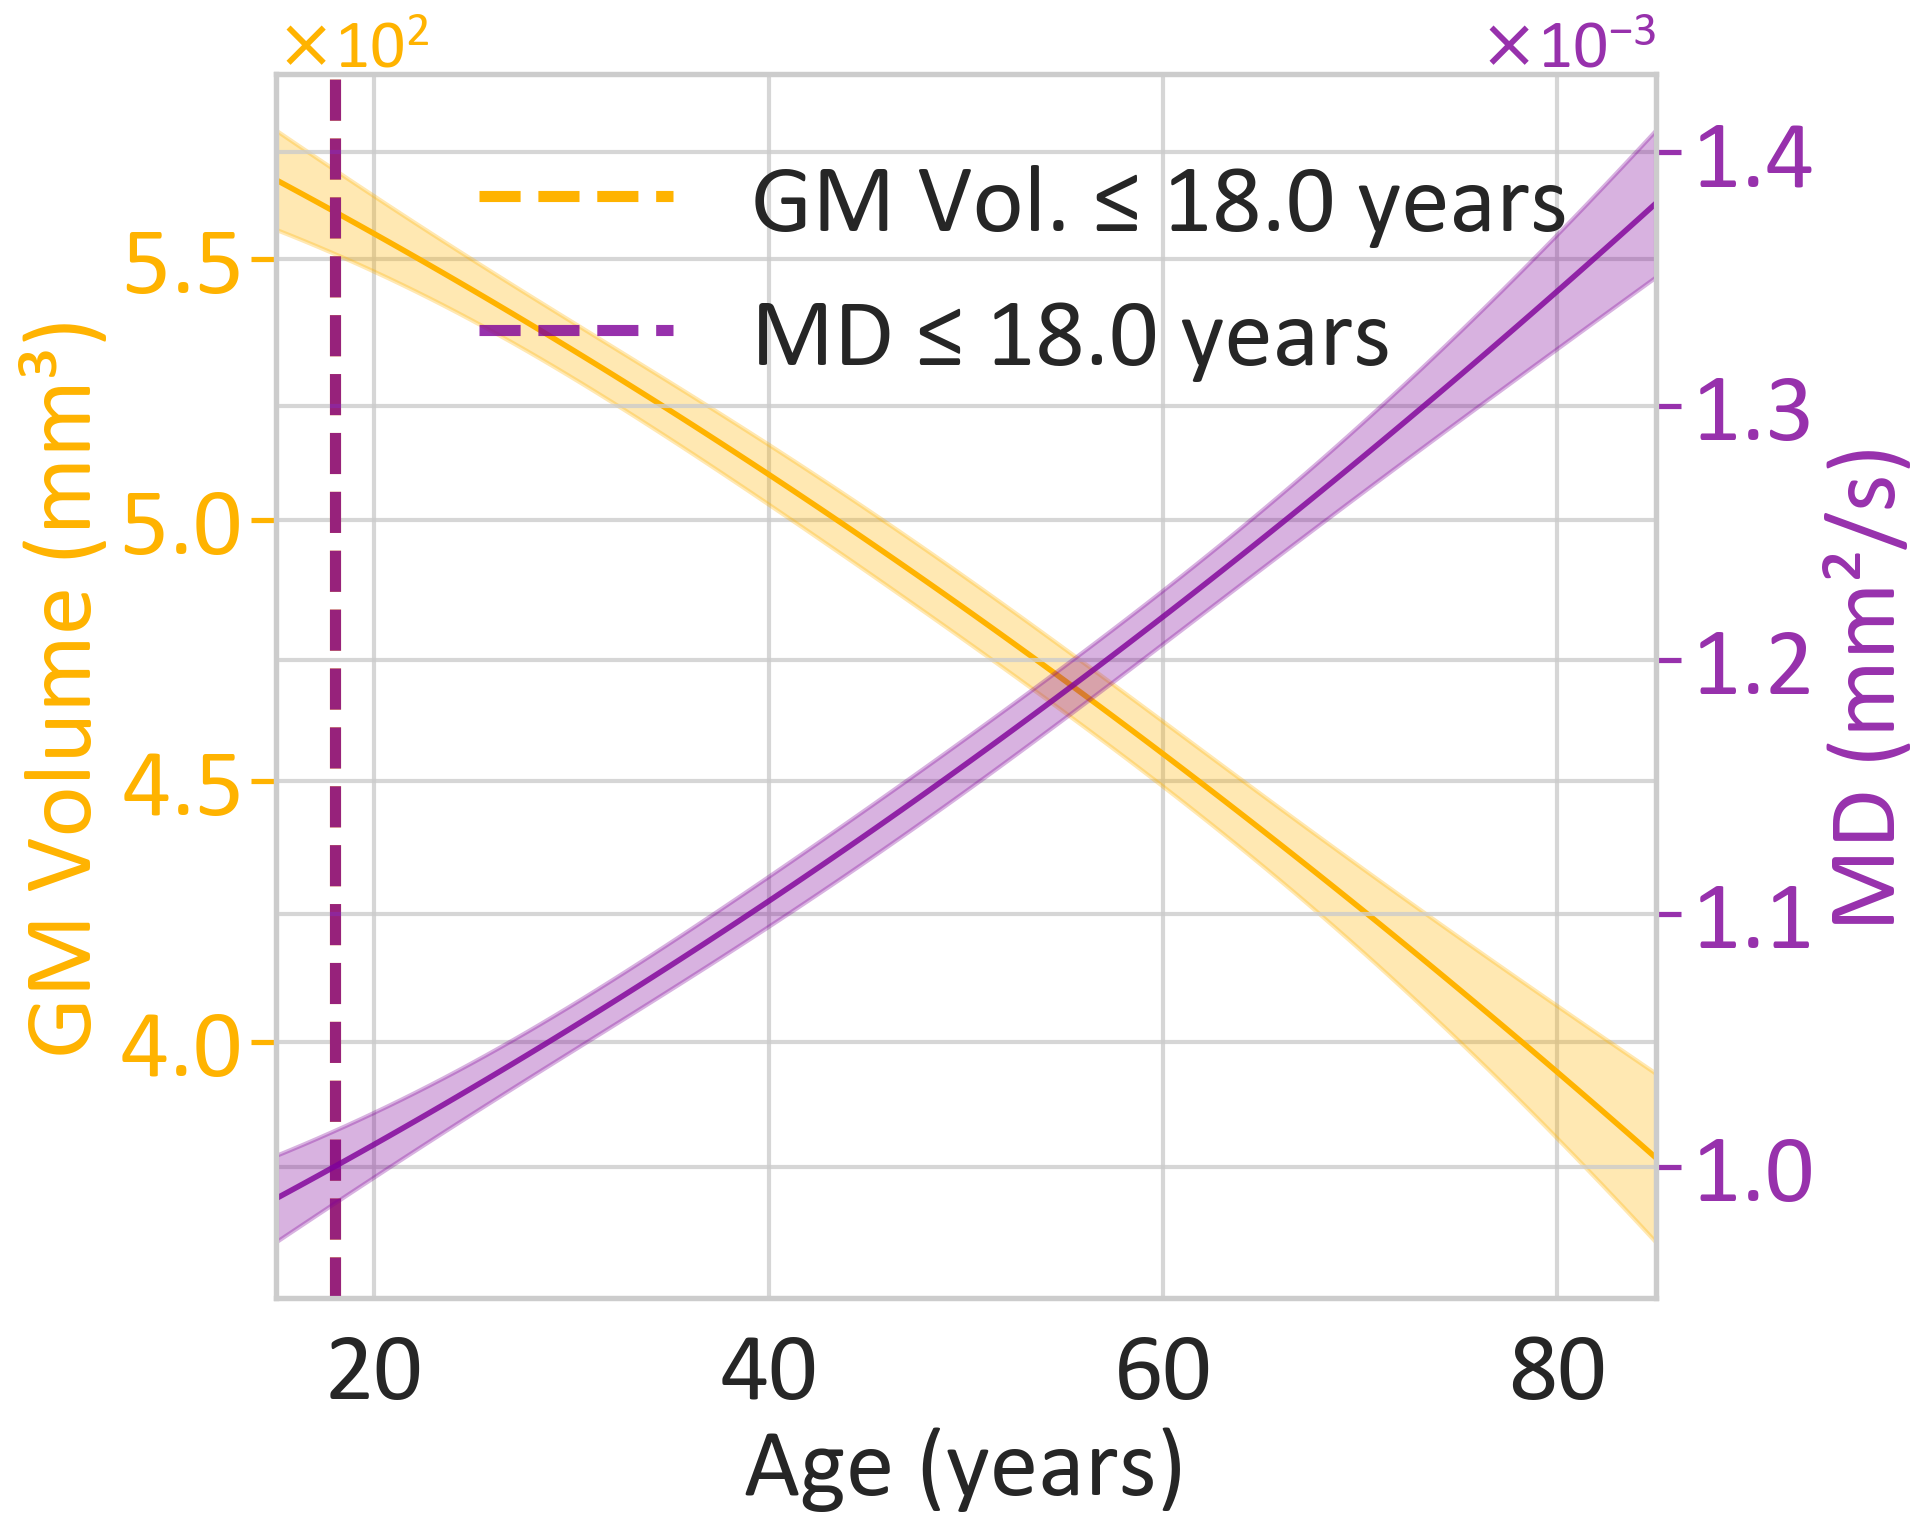

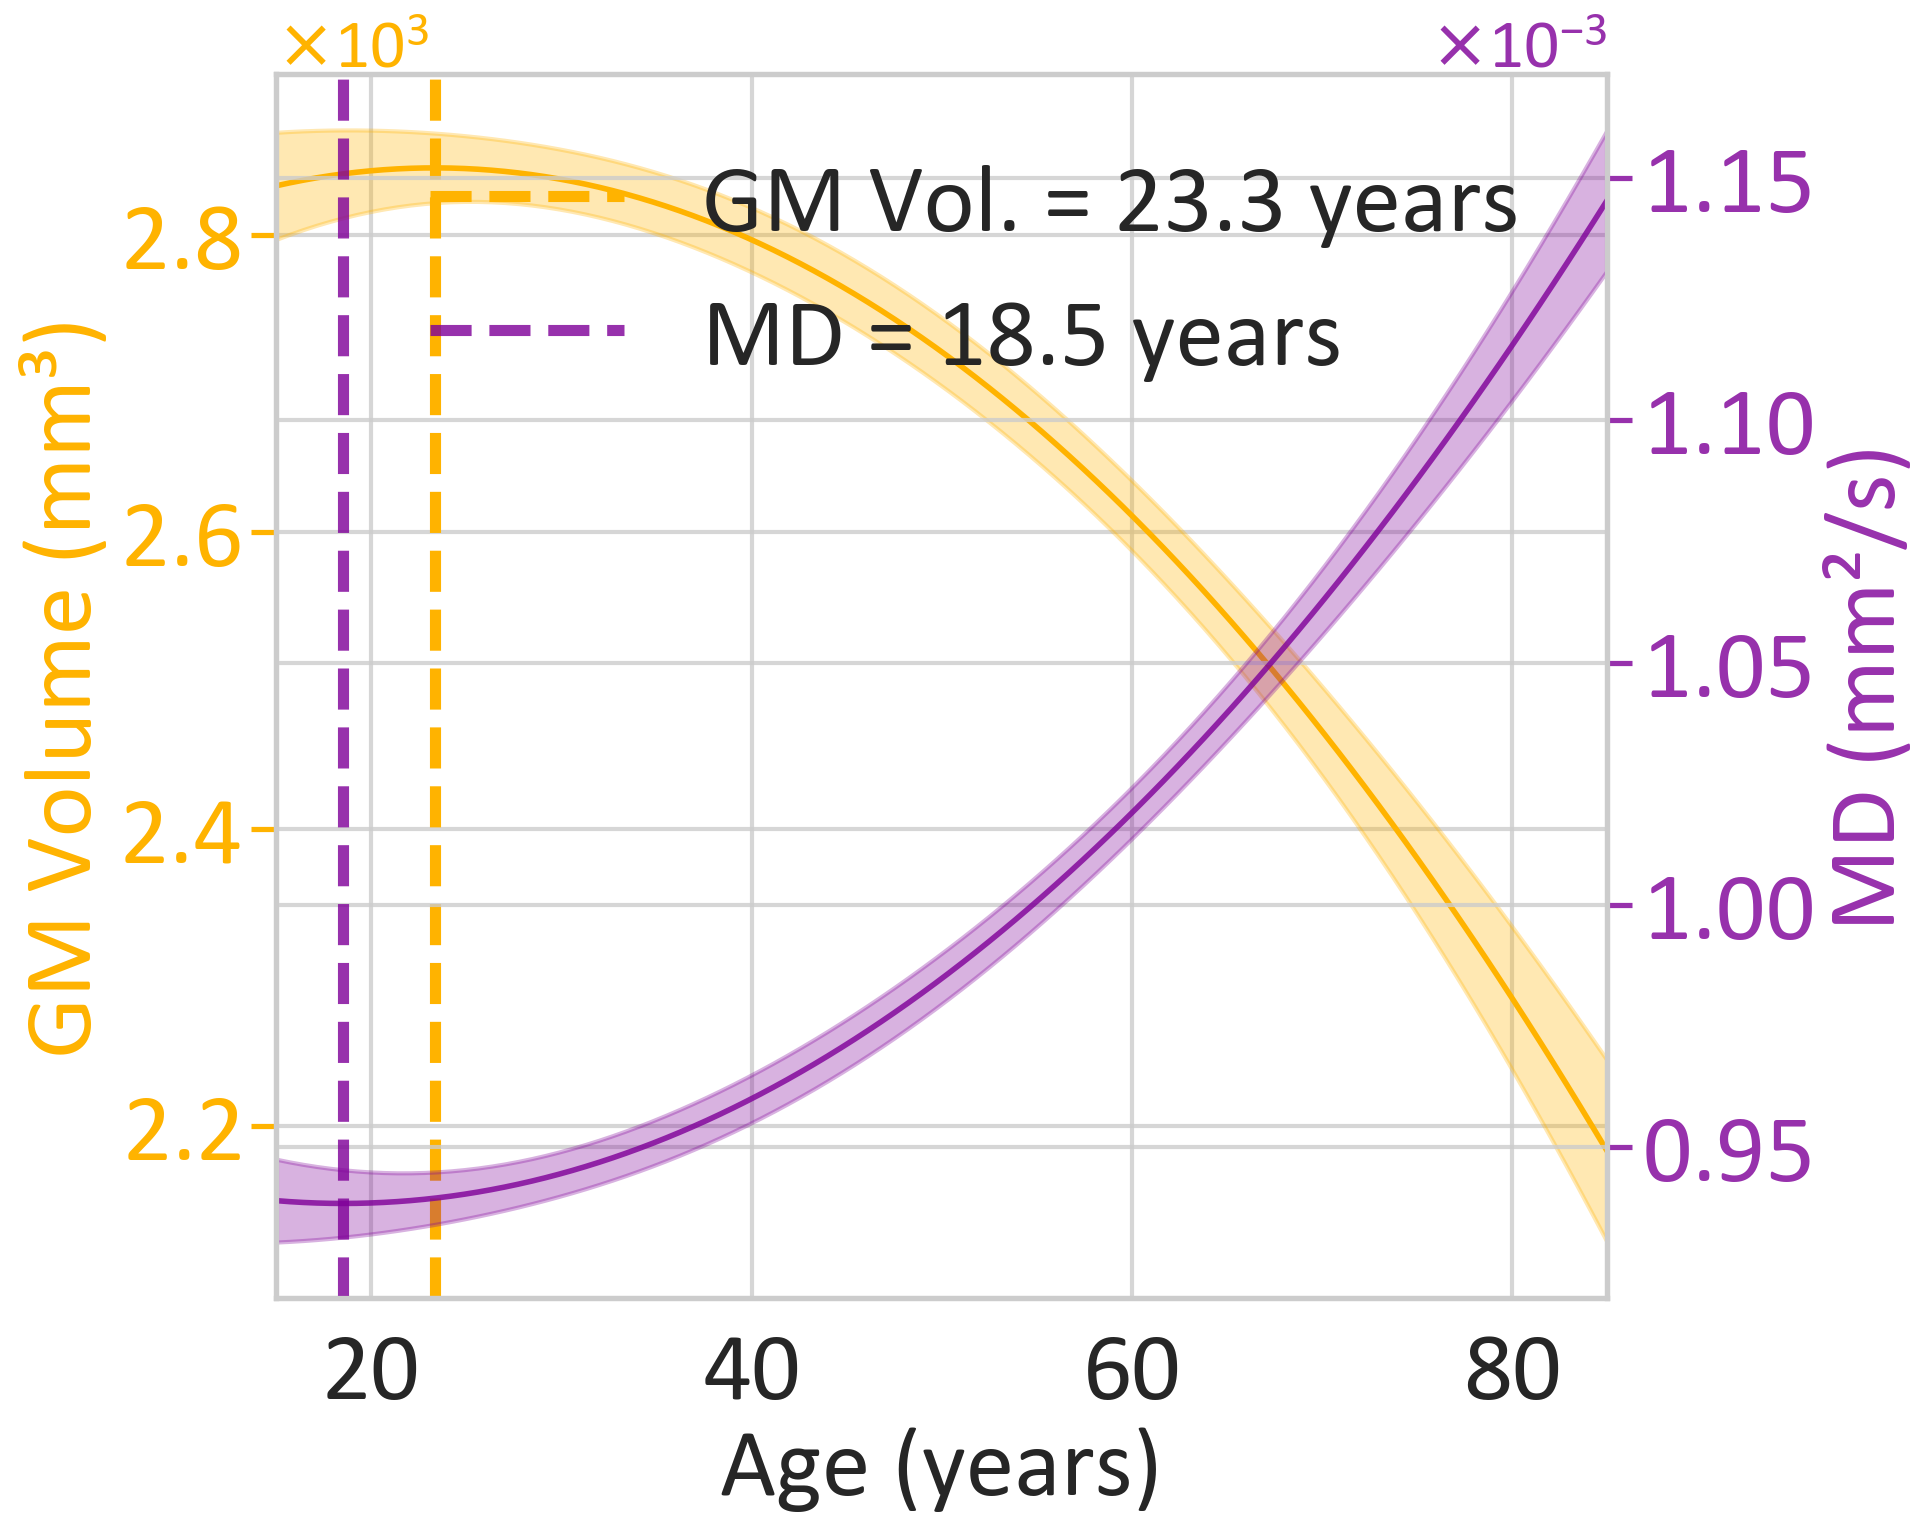

In [79]:
age_min, age_max = 15, 85
age_col = "age_c"

i = 413


# d = d[(d[metric_col] > d[metric_col].quantile(0.001))]

# ────────────────── Panel B: Predicted trajectory ± 95 % CI ──────────────

mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})

for i in example_rois:
    fig, ax1 = plt.subplots(figsize=(10, 8))
    ax2 = ax1.twinx()  # create a second y-axis for the second metric
    # move y label to the right for the second axis
    lines = []
    labels = []
    for metric, ax, color, sci_limits in zip(
        metrics, [ax1, ax2], [COL_RAW, COL_WEIGHTED], [(0, 0), (0, 100)]
    ):
        # stab_df = models[metric]["stab_df"]
        metric_col = metric_cols[metric]
        lm = regional_results[metric]["lin_w"].loc[i, "model"]
        qm = regional_results[metric]["quad_w"].loc[i, "model"]
        w_compare = regional_results[metric]["w_compare"]

        d = all_data[metric].copy()
        d = d[d[region_col] == parcels.loc[i, region_col]].copy()
        # remove outliers
        d = d[
            (d["value"] > d["value"].quantile(0.001)) & (d["value"] < d["value"].quantile(0.999))
        ]

        # 3. Prediction frame

        # ── 3. Prediction grid ──────────────────────────────────────────────
        is_centered = age_col == "age_c"
        if is_centered:
            mean_age = all_data[metric]["age_at_scan"].mean()
            age_grid = np.linspace(age_min - mean_age, age_max - mean_age, 100)
            age_grid_vis = age_grid + mean_age
        else:
            age_grid = np.linspace(age_min, age_max, 100)
            age_grid_vis = age_grid
        grid_df = pd.DataFrame({age_col: age_grid, "age_squared": age_grid**2})

        # add any covariates present in models (use median/mode)
        covs = [
            v
            for v in qm.model.exog_names
            if v not in ["Intercept", age_col, "age_c", "I(age_c ** 2)"]
        ]
        for c in covs:
            # if pd.api.types.is_numeric_dtype(d[c]):
            if "sex" in c:
                grid_df["sex"] = d["sex"].mode()[0]
            else:
                grid_df[c] = d[c].median()

        # 4. Get predictions & CI
        for tag, model in [("Linear", lm), ("Quadratic", qm)]:
            pr = model.get_prediction(grid_df)
            ci = pr.conf_int(alpha=0.05)
            grid_df[f"{tag}_fit"] = pr.predicted_mean
            grid_df[f"{tag}_lo"] = ci[:, 0]
            grid_df[f"{tag}_hi"] = ci[:, 1]
            print(metric, "---", tag, "---", model.rsquared_adj)
            # if is_centered:
            #     grid_df[f"{tag}_fit"] = grid_df[f"{tag}_fit"] + mean_age
            #     grid_df[f"{tag}_lo"] = grid_df[f"{tag}_lo"] + mean_age
            #     grid_df[f"{tag}_hi"] = grid_df[f"{tag}_hi"] + mean_age

        # 5. Plot
        ax.clear()  # reuse the same axes handle

        # Background scatter (down-sample for speed / clarity)
        sizes = np.clip(d["weight"] * 10, 0, 100)
        # sns.scatterplot(
        #     data=d,
        #     x=age_col,
        #     y="value",
        #     alpha=0.7,
        #     s=sizes,
        #     edgecolor="none",
        #     ax=ax,
        #     legend=False,
        #     color=COL_REF,
        # )
        is_quadratic = w_compare.loc[i, "delta_AIC"] < -15
        if is_quadratic:
            model = qm
        else:
            model = lm
        # # Fit lines & ribbons
        # for tag, color, model in zip(["Linear", "Quadratic"], [COL_RAW, COL_WEIGHTED], [lm, qm]):
        # label = f"{tag} - $R^2$ = {model.rsquared:.2f}, AIC = {model.aic:.1f}"
        label = f"{metric} - $R^2$ = {model.rsquared_adj:.2f}"
        lines.append(ax.plot(age_grid_vis, grid_df["Quadratic_fit"], label=label, lw=2, color=color))
        labels += [label]
        ax.fill_between(
            age_grid_vis,
            grid_df["Quadratic_lo"],
            grid_df["Quadratic_hi"],
            color=color,
            alpha=0.3,
        )

        # add age star
        stab_age = regional_results[metric]["quad_w"].loc[i, "age_star"]
        stab_age = stab_age if not np.isnan(stab_age) else 18
        metric_vis = metrics_vis.get(metric, metric)
        if stab_age > 18:
            # lab = f"Peak Structural Integrity (APSI) = {stab_age:.1f} years"
            lab = f"{metric_vis} = {stab_age:.1f} years"
        else:
            # lab = f"Peak Structural Integrity (APSI) ≤ {stab_age:.1f} years"
            lab = f"{metric_vis} ≤ {stab_age:.1f} years"

        # add an arrow pointing to the age star

        lines.append(
            ax.axvline(
                stab_age,
                color=color,
                linestyle="--",
                lw=4,
                label=lab,
            )
        )
        labels += [lab]
        if metric == "gm_vol":
            ylabel = "GM Volume (mm³)"
            # set y axis format to cm instead of mm
        else:
            ylabel = "MD (mm²/s)"

        ax.set(
            xlabel="Age (years)",
            ylabel=ylabel,
            xlim=(age_min, age_max),
        )
        # color the ylabel
        ax.yaxis.label.set_color(color)

        ax.ticklabel_format(style="sci", axis="y", scilimits=sci_limits, useMathText=True)

        # title = "(A) GM Volume" if metric == "gm_vol" else "(B) Mean Diffusivity"
        # suptitle = example_rois.get(i, {}).get("name", f"Region {i}")

        # ax.set_title("Predicted trajectory (± 95 % CI)")
        # ax.set_title(title, fontsize=30, pad=20)
        ax.tick_params(axis="both", which="major", labelsize=35)
        ax.tick_params(axis="y", which="major", color=color, labelcolor=color)

        # model_type = "quad" if use_quadratic else "linear"
    ax.legend(lines, labels, frameon=False, fontsize=35, loc="upper right")
    ax2.yaxis.set_label_position("right")
    # ax1.get_yaxis().get_offset_text().set_visible(False)
    ax2.yaxis.set_offset_position("right")
    # make sure the
    savefig_nice(
        fig,
        OUTPUT_DIR / f"fig3_{i+1}.png",
        tight=True,
        dpi=400,
    )
    # break
    # break

<Axes: xlabel='age_at_scan', ylabel='value'>

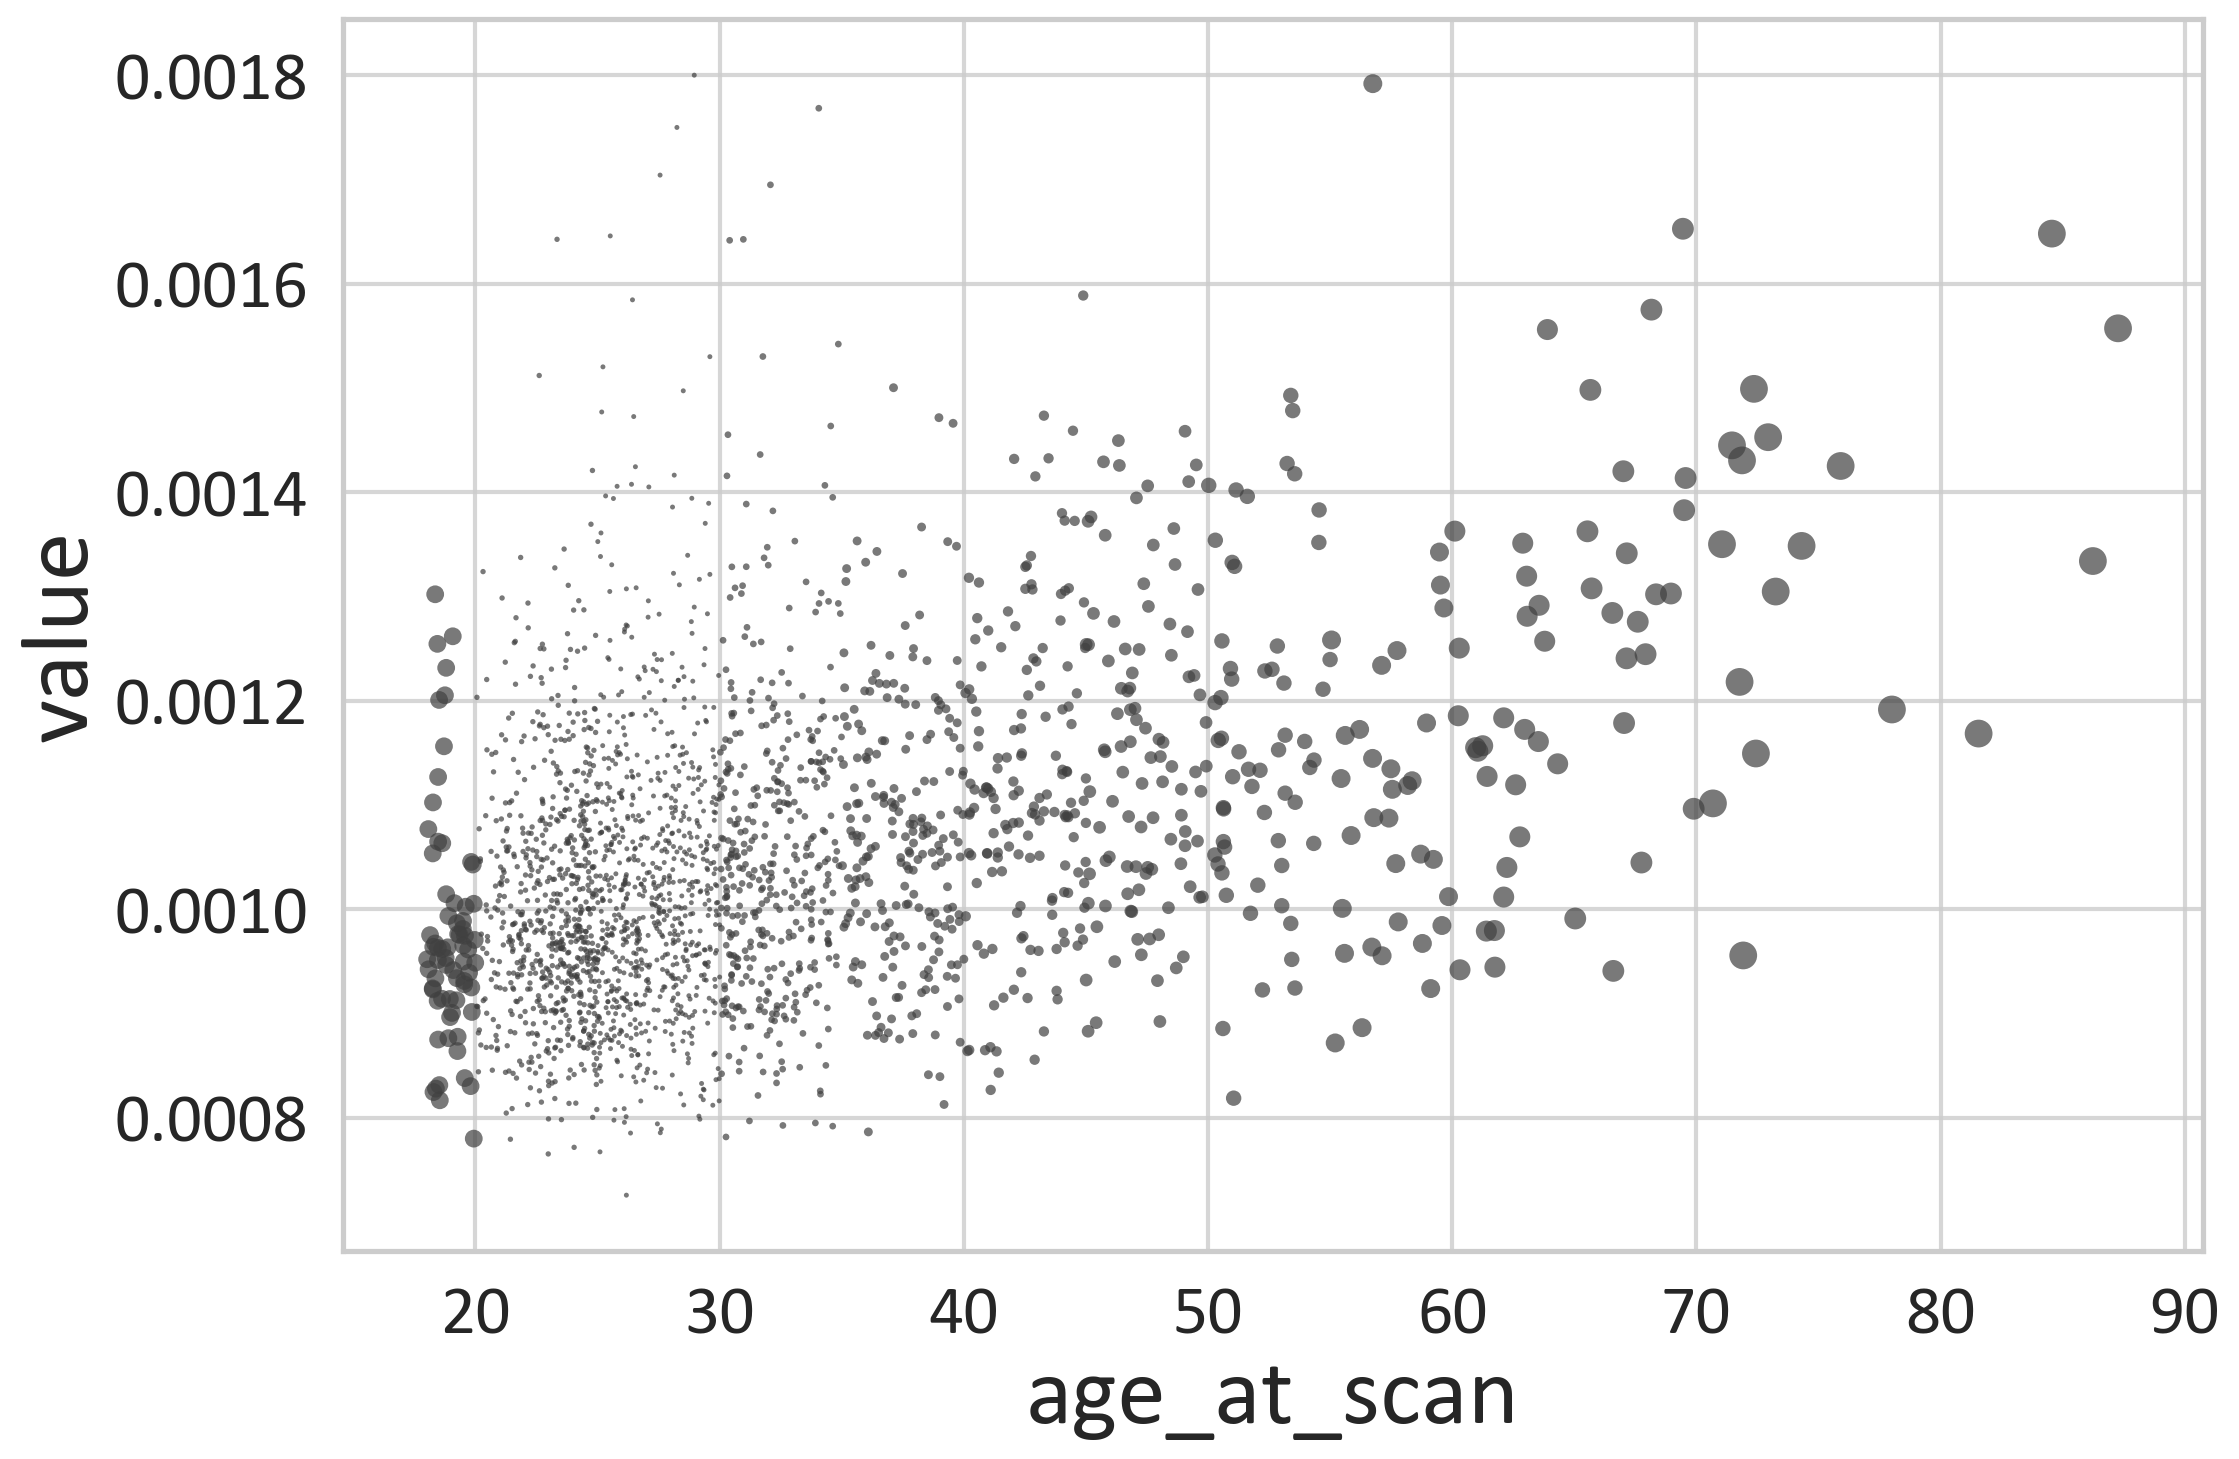

In [18]:
sns.scatterplot(
    data=d,
    x=age_col,
    y="value",
    alpha=0.7,
    s=sizes,
    edgecolor="none",
    # ax=ax,
    legend=False,
    color=COL_REF,
)

In [19]:
grid_df.loc[grid_df[age_col] == stab_age]

,age_at_scan,age_squared,sex,Linear_fit,Linear_lo,Linear_hi,Quadratic_fit,Quadratic_lo,Quadratic_hi


In [20]:
subcort_df.loc[48]

NameError: name 'subcort_df' is not defined

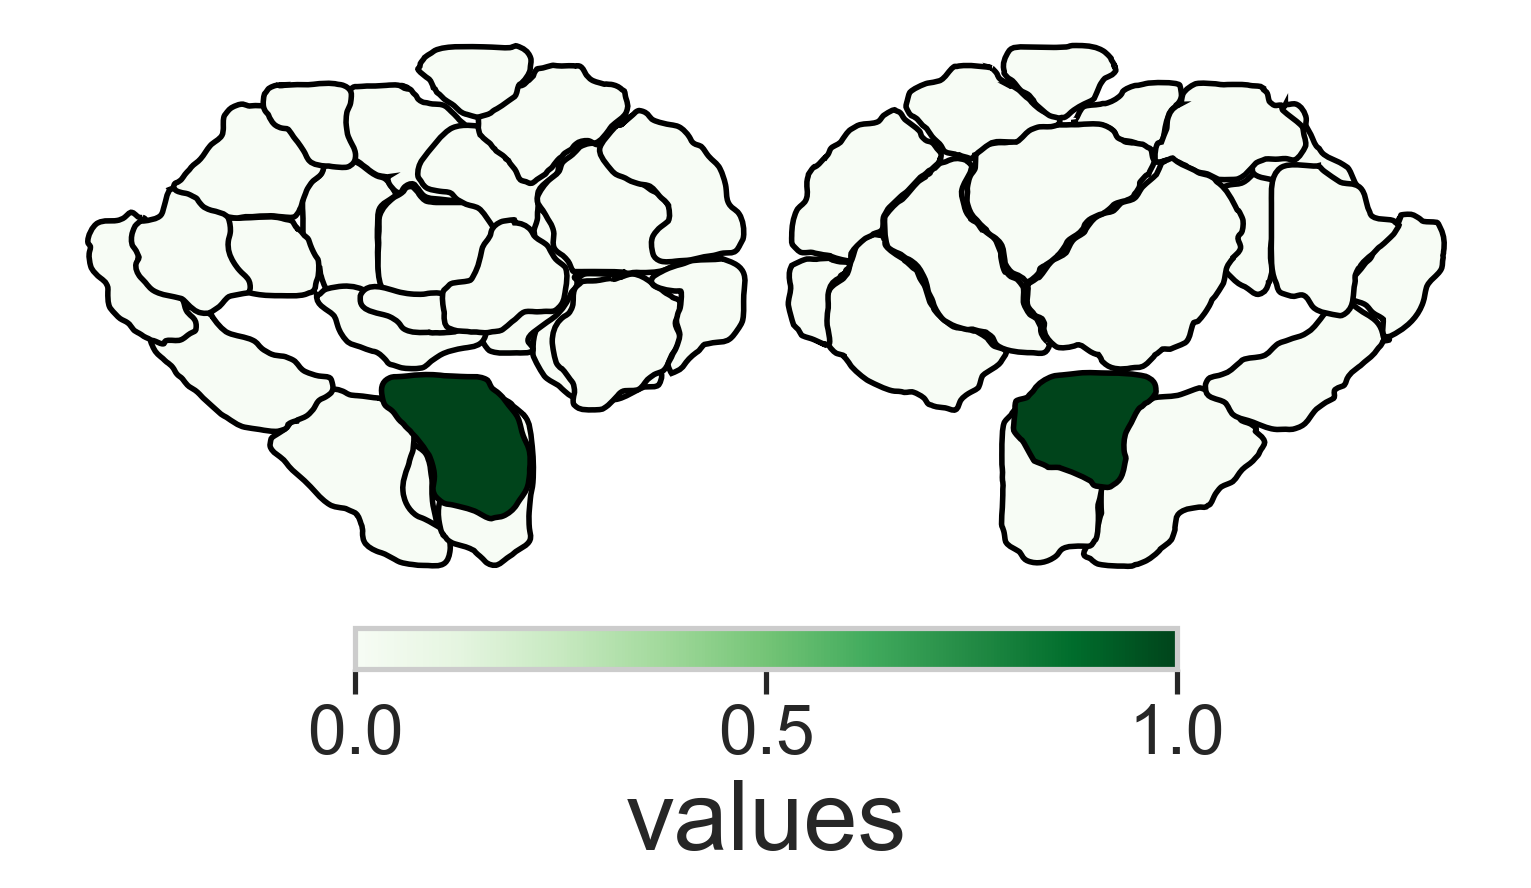

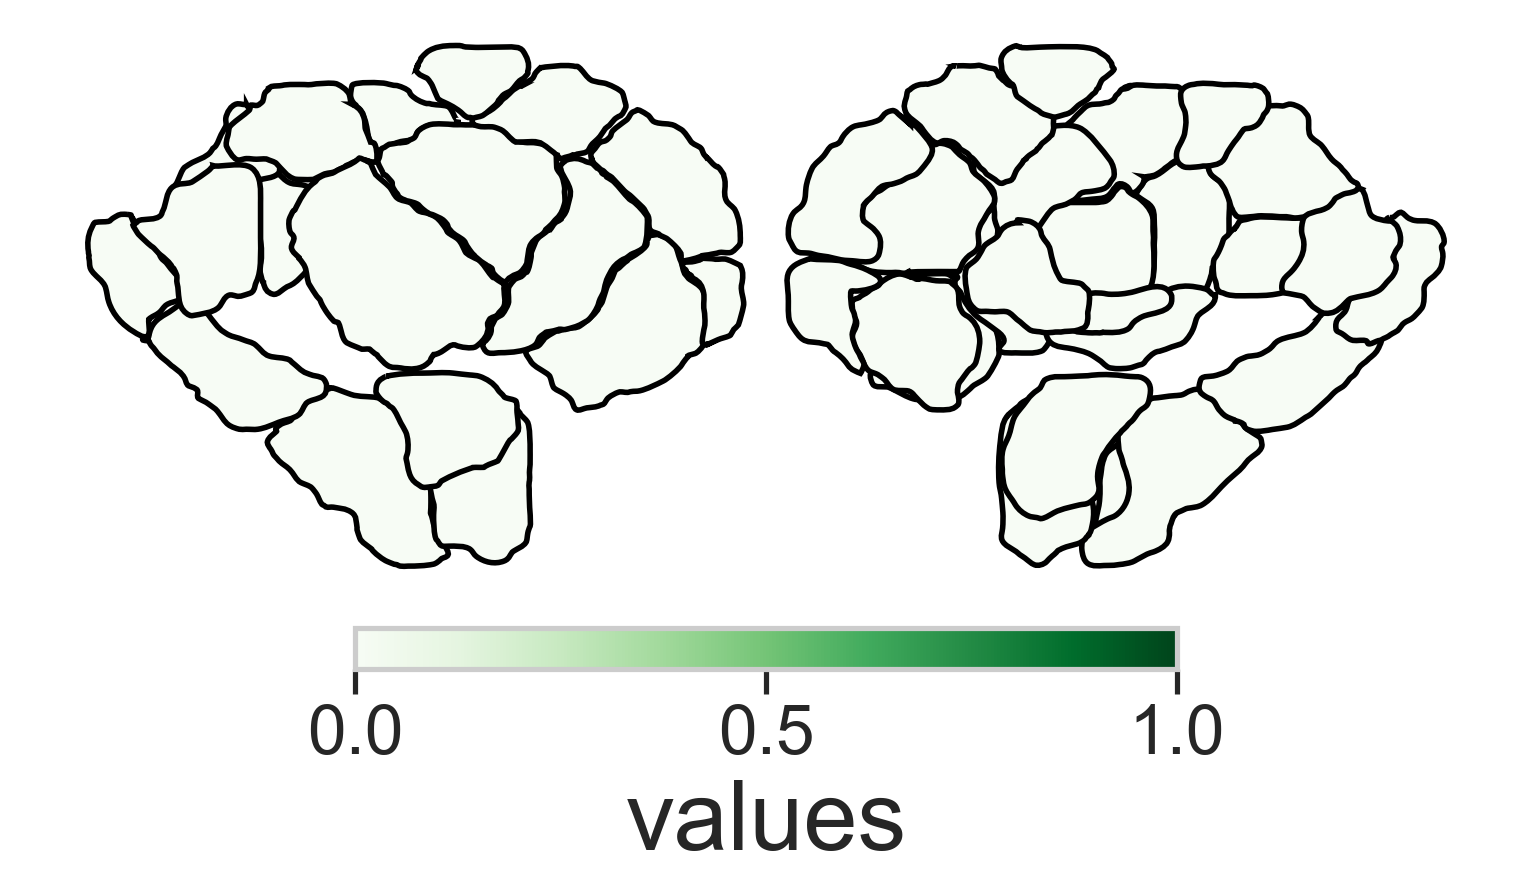

In [ ]:
from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
subcort_df["value"] = 0
subcort_df.loc[48, "value"] = 1
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


for hemi in ["L", "R"]:

    fig = plot_subcortical_data(
        subcort_df,
        atlas="Melbourne_S3",
        show_legend=True,
        hemisphere=hemi,
        # cmap="Purples",
        cmap="Greens",
        line_color="black",
        line_thickness=2,
        vmin=0,
        vmax=1,
        show_figure=False,
    )

    # save figure
    # savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib import font_manager as fm

# template colour palette
COL_GREY = "#575A5C"  # primary charcoal (axes / default bars)
COL_TEAL = "#21A0A0"  # accent / second category
COL_GRID = "#E5E5E5"  # light gridlines
COL_SAME = "#D81B60"  # Deep pink/magenta
# COL_SAME = COL_GREY
# COL_DIFF_REP = "#1E88E5"  # Blue for diff subj (repeated)
COL_DIFF_REP = COL_TEAL
# COL_DIFF_SINGLE = "#43A047"  # Green for diff subj (single)
COL_DIFF_SINGLE = COL_GREY  # Green for diff subj (single)

In [ ]:
i = 413
age_min = 18
age_max = 85
n_grid = 100

age_col = "age_at_scan"

d = data[data[region_col] == parcels.loc[i, region_col]].copy()

lm_res = models["lin_w"].loc[i, "model"]
qm_res = models["quad_w"].loc[i, "model"]
stab_row = stab_df.loc[i]
age_star = stab_row["age_star"]

# ── 3. Prediction grid ──────────────────────────────────────────────
age_grid = np.linspace(age_min, age_max, n_grid)
grid_df = pd.DataFrame({age_col: age_grid, "age_squared": age_grid**2})

# add any covariates present in models (use median/mode)
covs = [v for v in qm_res.model.exog_names if v not in ["Intercept", age_col, "age_squared"]]
for c in covs:
    if pd.api.types.is_numeric_dtype(data[c]):
        grid_df[c] = d[c].median()
    else:
        grid_df[c] = d[c].mode()[0]

KeyError: 'I(age_at_scan ** 2)'

In [ ]:
# predictions
def pred_ci(model):
    pr = model.get_prediction(grid_df)
    ci = pr.conf_int(alpha=0.05)
    return pr.predicted_mean, ci[:, 0], ci[:, 1]


fit_lin, lo_lin, hi_lin = pred_ci(lm_res)
fit_quad, lo_quad, hi_quad = pred_ci(qm_res)

(0.00036080126405744497, 0.0008791290586740551)

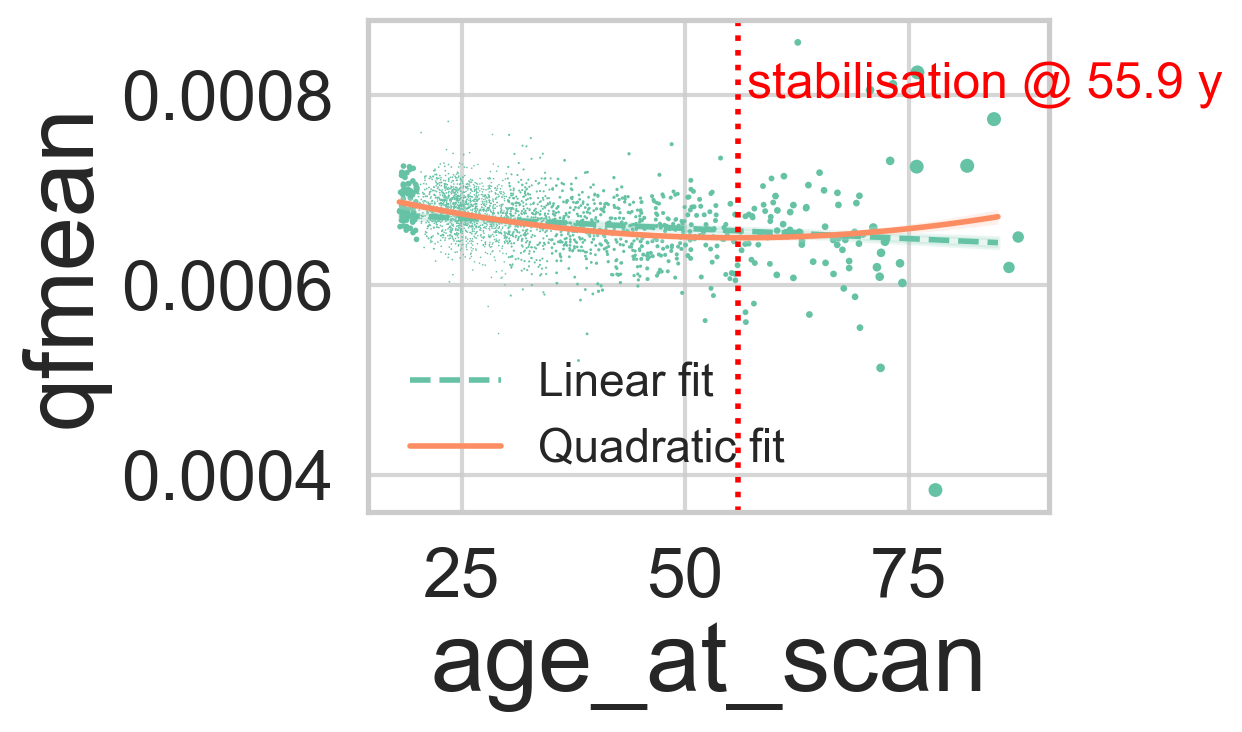

In [ ]:
weight_col = "weight"
# ── 4. Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

# scatter of raw points
size_kw = {} if weight_col is None else {"s": d[weight_col]}
sns.scatterplot(
    data=d,
    x=age_col,
    y=metric_col,
    # alpha=scatter_alpha,
    edgecolor="none",
    ax=ax,
    legend=False,
    **size_kw,
)

# linear fit
ax.plot(age_grid, fit_lin, ls="--", lw=2, label="Linear fit")
ax.fill_between(age_grid, lo_lin, hi_lin, alpha=0.15, color="C0")

# quadratic fit
ax.plot(age_grid, fit_quad, lw=2, label="Quadratic fit")
ax.fill_between(age_grid, lo_quad, hi_quad, alpha=0.15)

# stabilisation age
ax.axvline(age_star, ls=":", lw=2, color="red")
ax.text(
    age_star + 1,
    ax.get_ylim()[1] * 0.95,
    f"stabilisation @ {age_star:.1f} y",
    color="red",
    va="top",
)

# ax.set(xlabel="Age (years)", ylabel=f"{metric} value", title=f"Region {region_id} • {metric}")
ax.legend(frameon=False)
fig.tight_layout()
ax.set_ylim(
    # ax.get_ylim()[0] * 0.95,
    # ax.get_ylim()[1] * 1.05,
    # 0.0005,0.0008
)

In [ ]:
# ── Helper: per-region demonstration plot ──────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_region_fit(
    region_id,
    metric,
    df_long,
    *,
    lm_dict,
    qm_dict,
    stab_df,
    age_col="age_at_scan",
    value_col="value",
    weight_col=None,  # set to "weight" if you want weighted sizes
    age_min=18,
    age_max=85,
    n_grid=300,
    scatter_alpha=0.25,
):
    """
    Parameters
    ----------
    region_id   : hashable region label used in lm_dict / qm_dict keys
    metric      : str, metric name (e.g. "gm_vol" or "adc")
    df_long     : DataFrame with columns [region_id, age_col, value_col, weight_col]
    lm_dict     : {region_id: statsmodels.RegressionResults}  (linear fits)
    qm_dict     : {region_id: statsmodels.RegressionResults}  (quadratic fits)
    stab_df     : DataFrame with columns ['region', 'stabilisation_age', 'model']
    weight_col  : if not None, point size ∝ weight
    """
    # ── 1. Slice data for this region ────────────────────────────────────
    d = df_long[df_long["region"] == region_id].copy()

    # ── 2. Retrieve models & stabilisation age ──────────────────────────
    lm_res = lm_dict[region_id]
    qm_res = qm_dict[region_id]
    stab_row = stab_df.loc[stab_df["region"] == region_id].iloc[0]
    age_star = stab_row["age_star"]

    # ── 3. Prediction grid ──────────────────────────────────────────────
    age_grid = np.linspace(age_min, age_max, n_grid)
    grid_df = pd.DataFrame({age_col: age_grid})

    # add any covariates present in models (use median/mode)
    covs = [
        v for v in lm_res.model.exog_names if v not in ["Intercept", age_col, f"I({age_col} ** 2)"]
    ]
    for c in covs:
        if pd.api.types.is_numeric_dtype(df_long[c]):
            grid_df[c] = df_long[c].median()
        else:
            grid_df[c] = df_long[c].mode()[0]

    # predictions
    def pred_ci(model):
        pr = model.get_prediction(grid_df)
        ci = pr.conf_int(alpha=0.05)
        return pr.predicted_mean, ci[:, 0], ci[:, 1]

    fit_lin, lo_lin, hi_lin = pred_ci(lm_res)
    fit_quad, lo_quad, hi_quad = pred_ci(qm_res)

    # ── 4. Plot ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 4))

    # scatter of raw points
    size_kw = {} if weight_col is None else {"s": 30 * d[weight_col]}
    sns.scatterplot(
        data=d,
        x=age_col,
        y=value_col,
        alpha=scatter_alpha,
        edgecolor="none",
        ax=ax,
        legend=False,
        **size_kw,
    )

    # linear fit
    ax.plot(age_grid, fit_lin, ls="--", lw=2, label="Linear fit")
    ax.fill_between(age_grid, lo_lin, hi_lin, alpha=0.15)

    # quadratic fit
    ax.plot(age_grid, fit_quad, lw=2, label="Quadratic fit")
    ax.fill_between(age_grid, lo_quad, hi_quad, alpha=0.15)

    # stabilisation age
    ax.axvline(age_star, ls=":", lw=2, color="red")
    ax.text(
        age_star + 1,
        ax.get_ylim()[1] * 0.95,
        f"stabilisation @ {age_star:.1f} y",
        color="red",
        va="top",
    )

    ax.set(xlabel="Age (years)", ylabel=f"{metric} value", title=f"Region {region_id} • {metric}")
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax